In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Plot settings
plt.style.use("ggplot")
sns.set_palette("viridis")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("earthquake_1995-2023.csv")

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])


Rows : 1000
Columns : 19


In [5]:
df.columns

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,1000,984,"M 6.5 - Kermadec Islands, New Zealand",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
magnitude,1000.0,NaN,NaN,NaN,6.94015,0.438148,6.5,6.6,6.8,7.1,9.1
date_time,1000,990,11-01-2022 12:39,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cdi,1000.0,NaN,NaN,NaN,3.605,3.328972,0.0,0.0,4.0,7.0,9.0
mmi,1000.0,NaN,NaN,NaN,6.027,1.43399,1.0,5.0,6.0,7.0,10.0
alert,449,4,green,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsunami,1000.0,NaN,NaN,NaN,0.325,0.468609,0.0,0.0,0.0,1.0,1.0
sig,1000.0,NaN,NaN,NaN,847.915,301.802632,650.0,691.0,744.0,874.25,2910.0
net,1000,11,us,960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nst,1000.0,NaN,NaN,NaN,193.918,239.045858,0.0,0.0,0.0,403.0,934.0


In [12]:
df.isnull().sum().sort_values(ascending=False)

continent    716
alert        551
country      349
location       6
dmin           0
longitude      0
latitude       0
depth          0
magType        0
gap            0
title          0
magnitude      0
net            0
sig            0
tsunami        0
mmi            0
cdi            0
date_time      0
nst            0
dtype: int64

In [13]:
missing = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":round(df.isnull().mean()*100,2)
})

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage
continent,716,71.6
alert,551,55.1
country,349,34.9
location,6,0.6
dmin,0,0.0
longitude,0,0.0
latitude,0,0.0
depth,0,0.0
magType,0,0.0
gap,0,0.0


In [14]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [15]:
df.drop_duplicates(inplace=True)

print(df.shape)

(1000, 19)


In [16]:
df.dtypes

title         object
magnitude    float64
date_time     object
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
net           object
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
location      object
continent     object
country       object
dtype: object

In [17]:
df['date_time']=pd.to_datetime(df['date_time'])

In [18]:
df["Year"]=df["date_time"].dt.year
df["Month"]=df["date_time"].dt.month
df["Day"]=df["date_time"].dt.day
df["Hour"]=df["date_time"].dt.hour

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,Year,Month,Day,Hour
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu,2023,8,16,12
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN,2023,7,19,0
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,2023,7,17,3
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN,2023,7,16,6
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN,2023,7,16,6


In [19]:
numerical=df.select_dtypes(include=np.number)

numerical.columns

Index(['magnitude', 'cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap',
       'depth', 'latitude', 'longitude', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

In [20]:
categorical=df.select_dtypes(include="object")

categorical.columns

Index(['title', 'alert', 'net', 'magType', 'location', 'continent', 'country'], dtype='object')

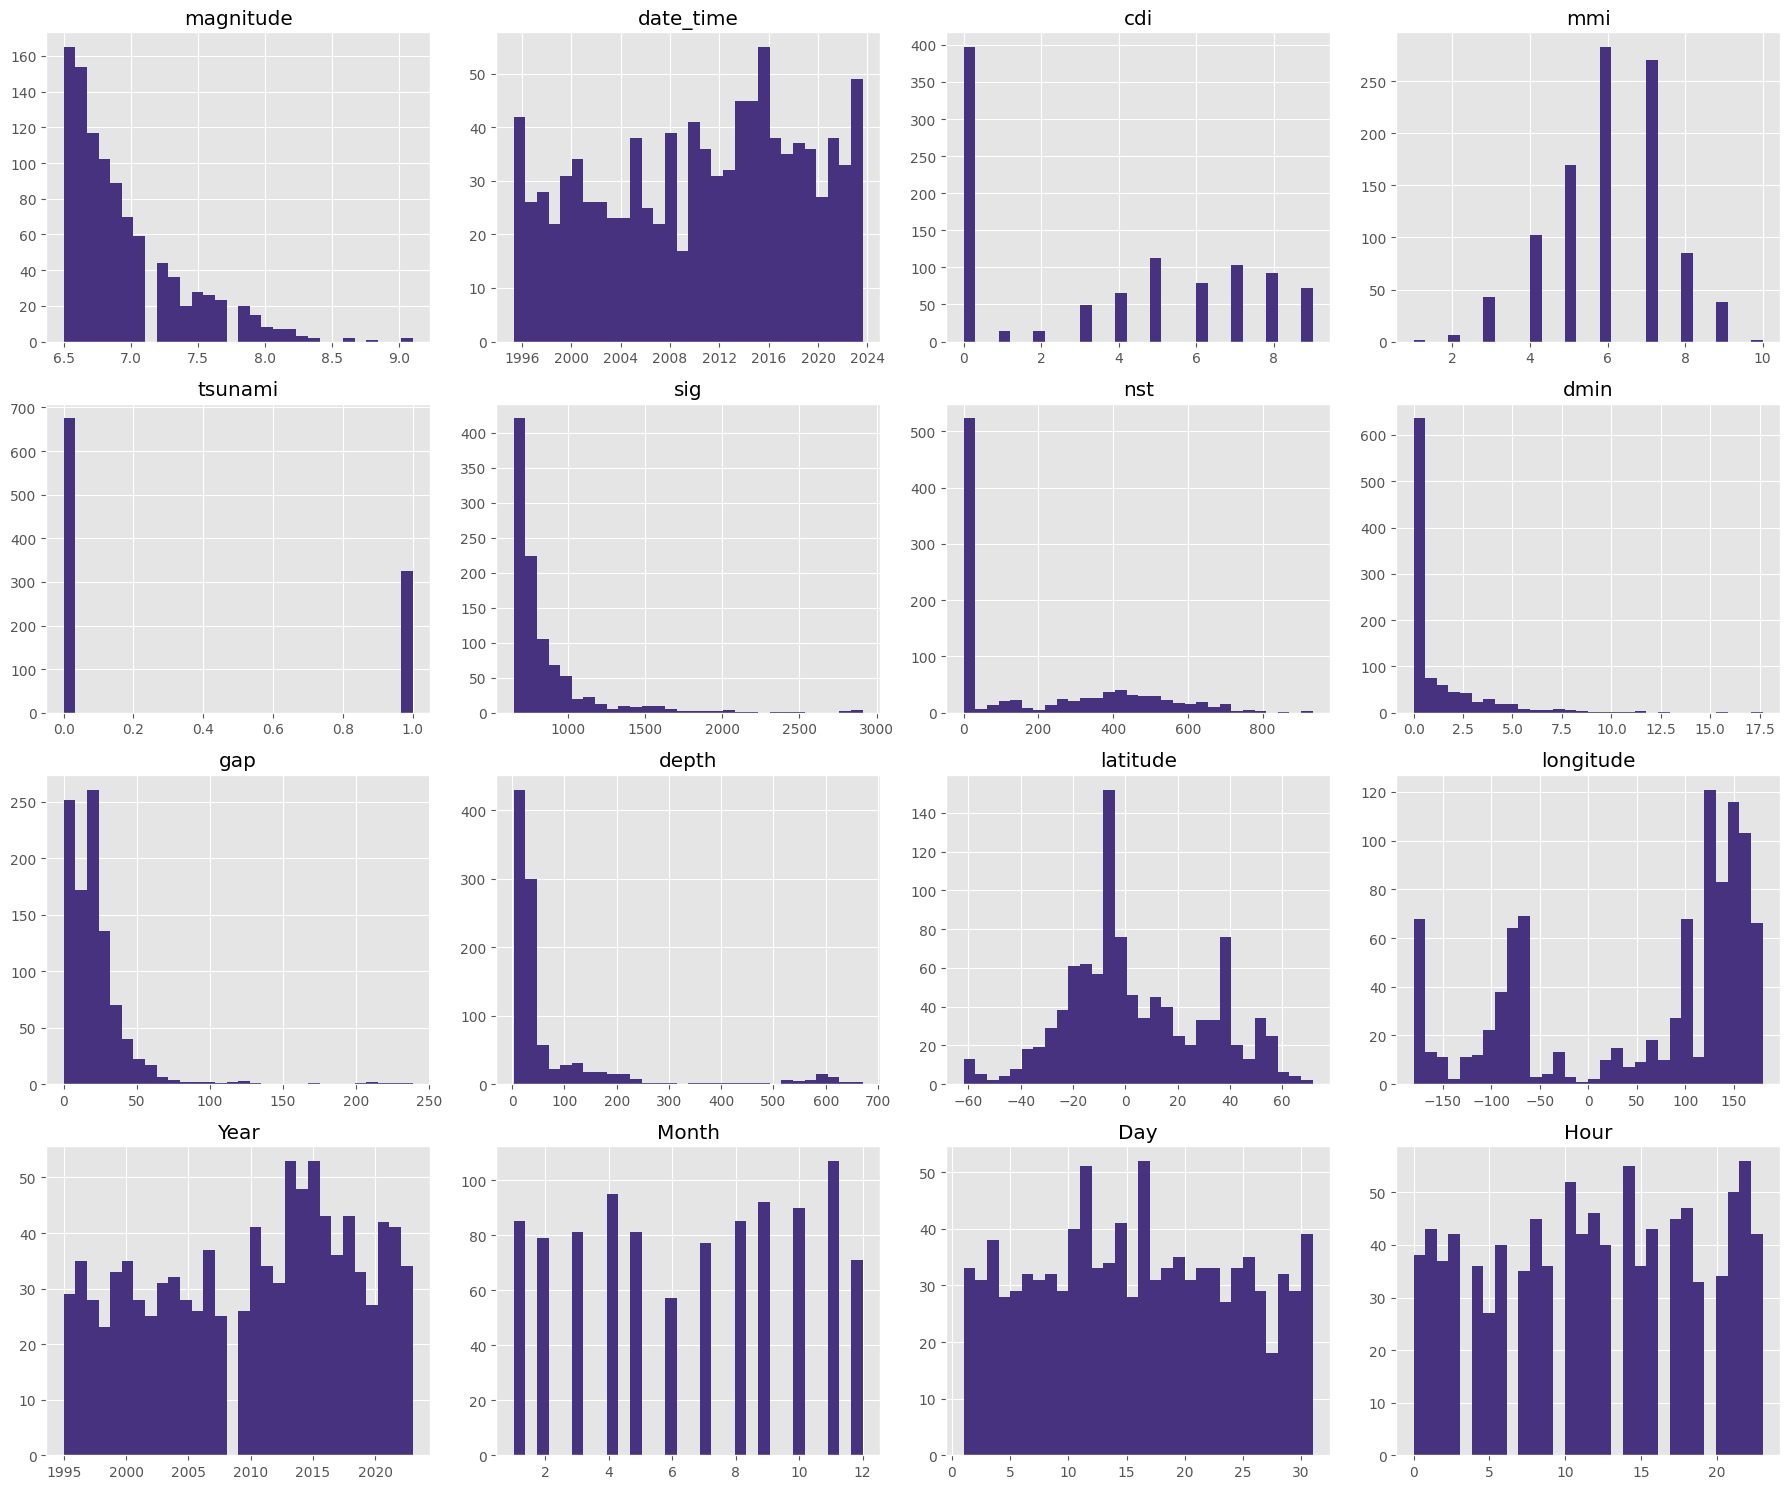

In [21]:
df.hist(figsize=(18,15),bins=30)

plt.tight_layout()

plt.show()

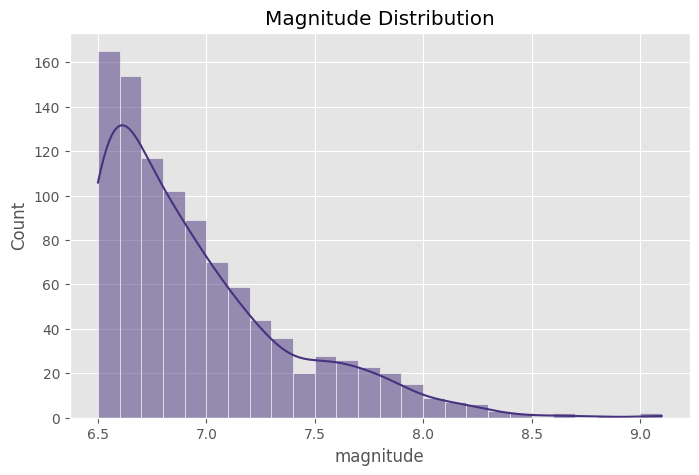

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["magnitude"],kde=True)

plt.title("Magnitude Distribution")

plt.show()

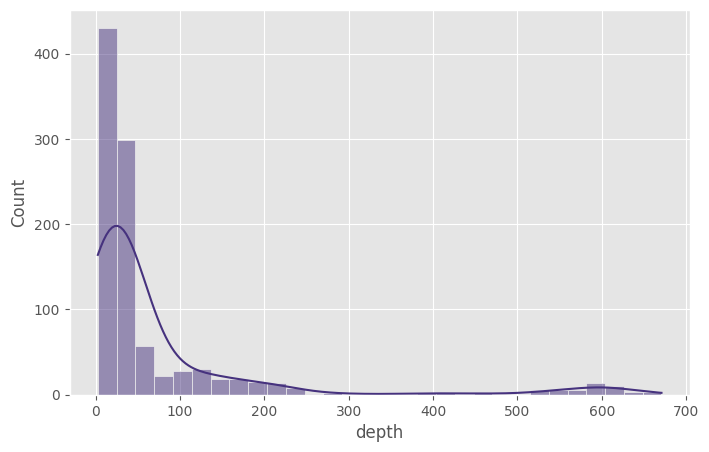

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["depth"],bins=30,kde=True)

plt.show()

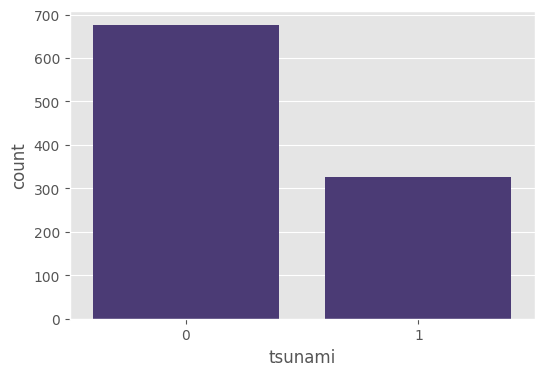

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="tsunami",data=df)

plt.show()

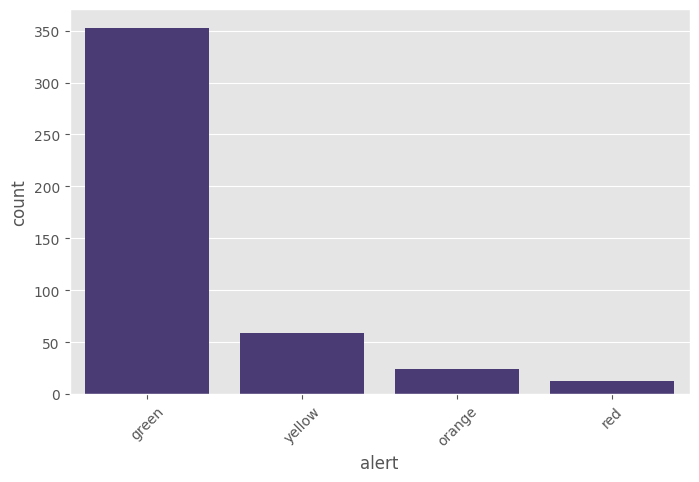

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x="alert",data=df)

plt.xticks(rotation=45)

plt.show()

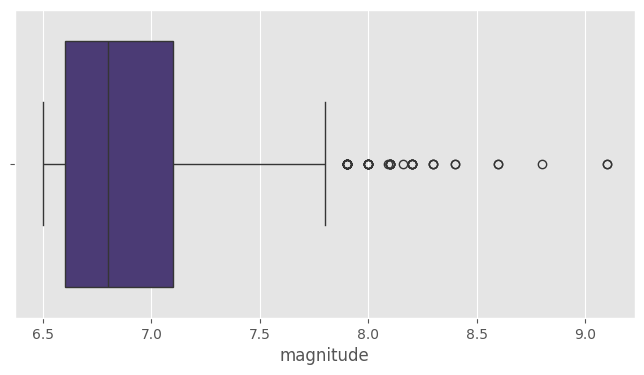

In [26]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["magnitude"])

plt.show()

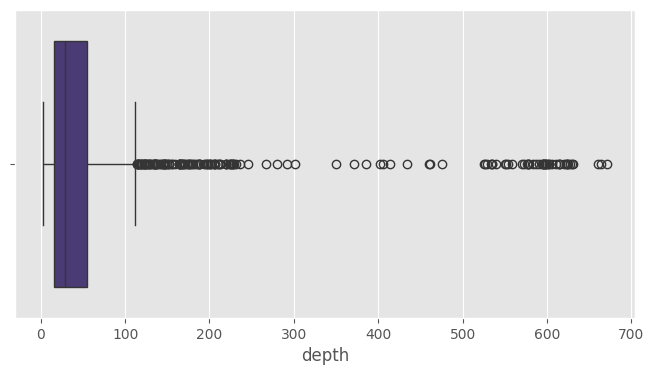

In [27]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["depth"])

plt.show()

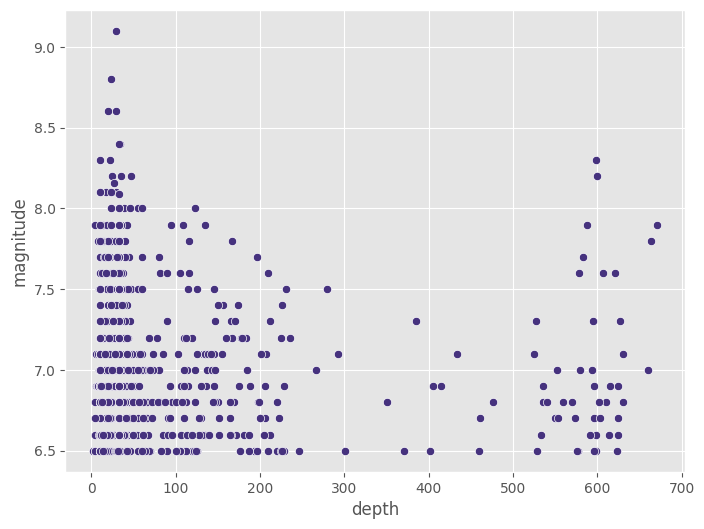

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="depth",
    y="magnitude",
    data=df
)

plt.show()

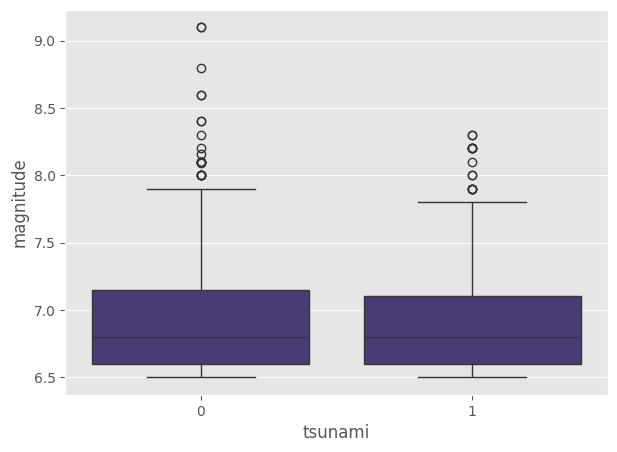

In [34]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="tsunami",
    y="magnitude",
    data=df
)

plt.show()

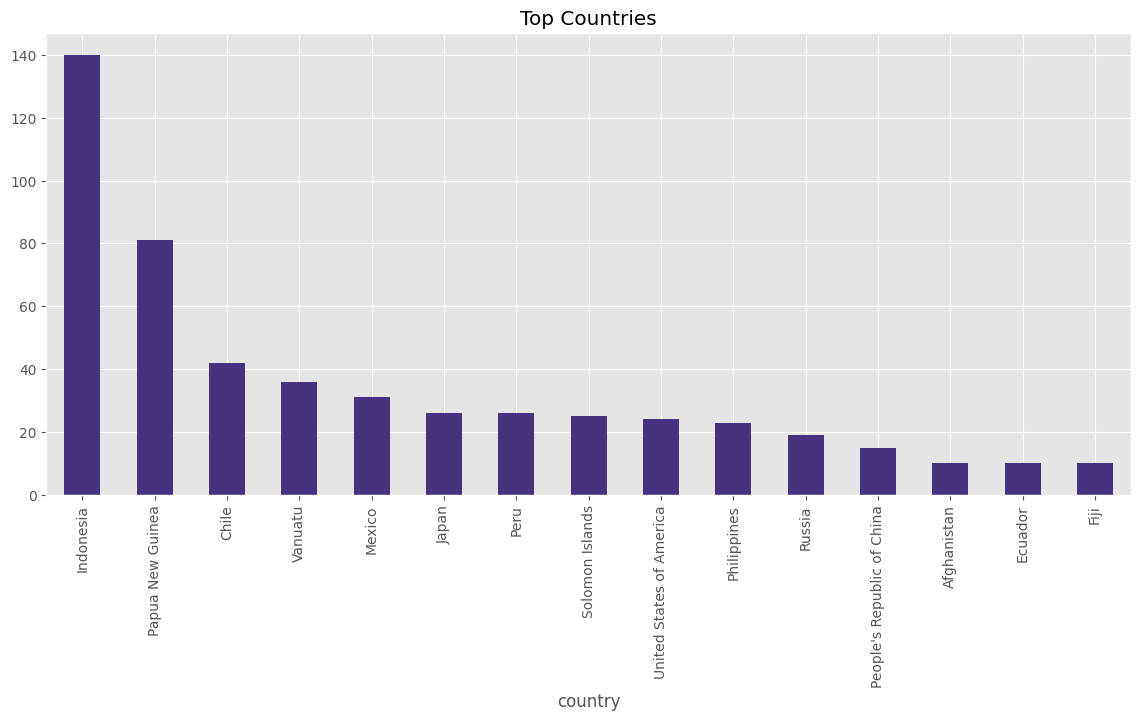

In [35]:
plt.figure(figsize=(14,6))

df["country"].value_counts().head(15).plot(kind="bar")

plt.title("Top Countries")

plt.show()

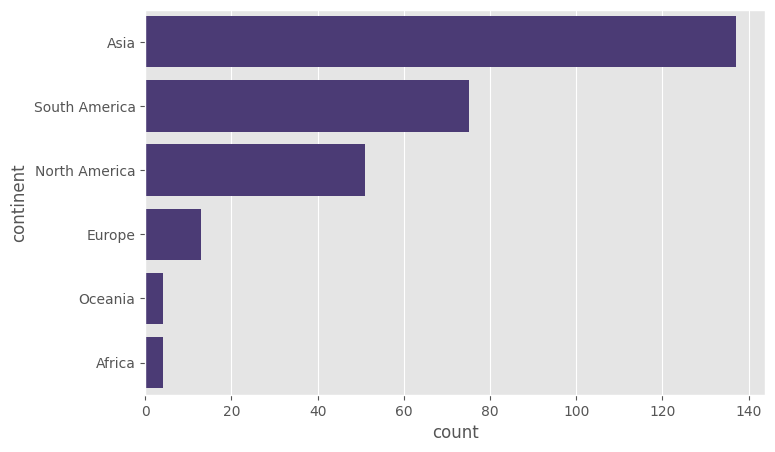

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="continent",
    data=df,
    order=df["continent"].value_counts().index
)

plt.show()

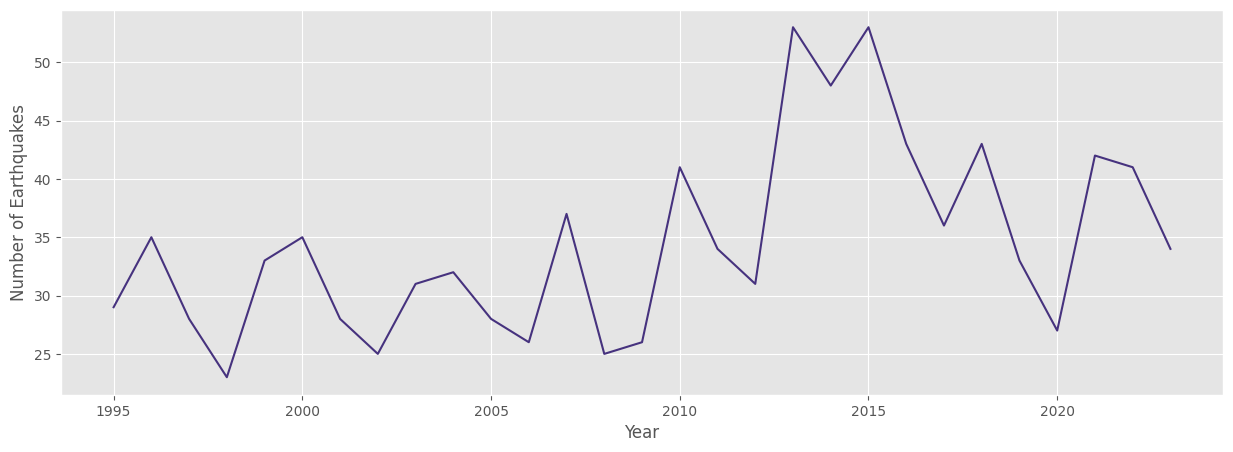

In [37]:
plt.figure(figsize=(15,5))

df["Year"].value_counts().sort_index().plot()

plt.xlabel("Year")

plt.ylabel("Number of Earthquakes")

plt.show()

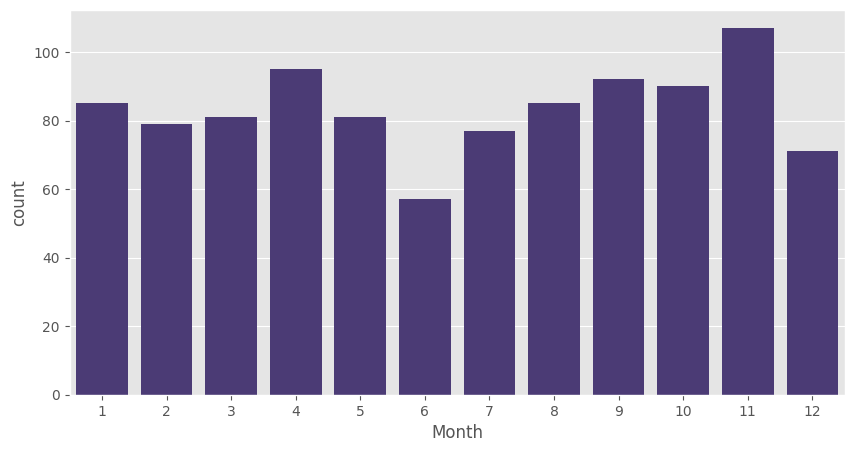

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(x="Month",data=df)

plt.show()

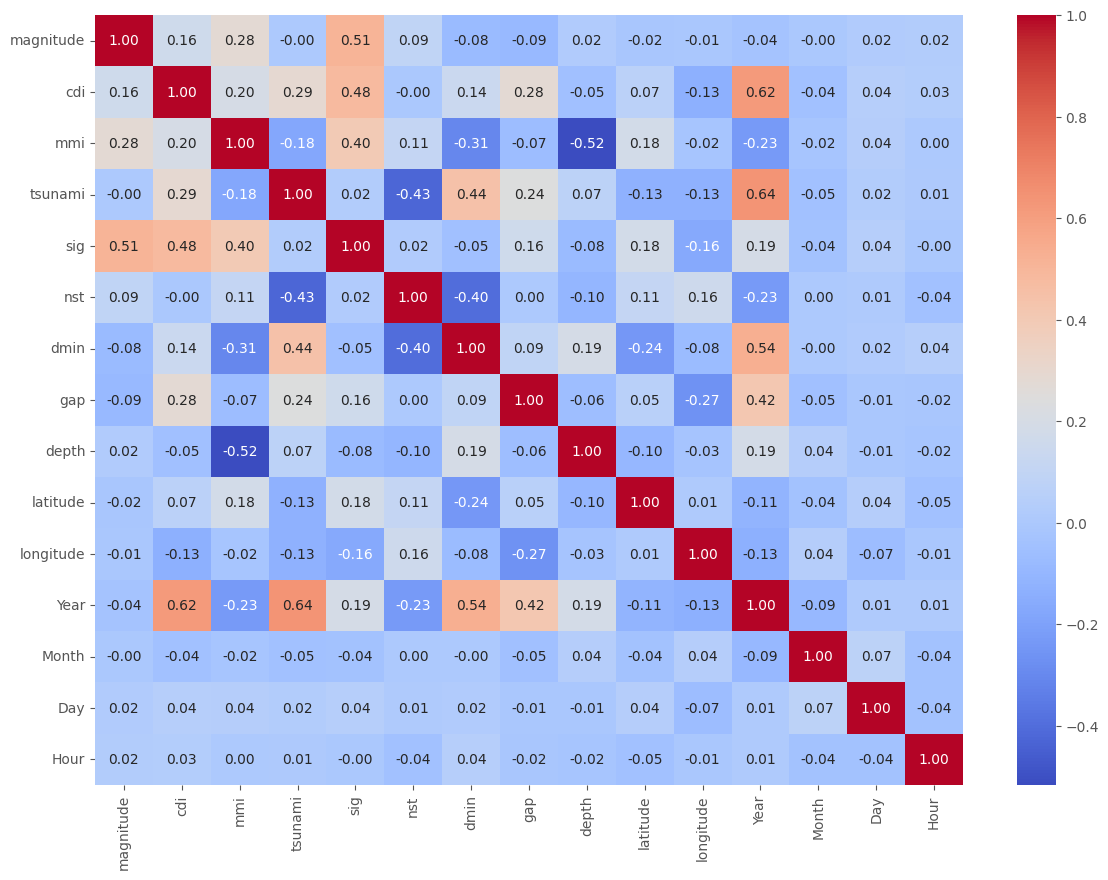

In [39]:
plt.figure(figsize=(14,10))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.show()

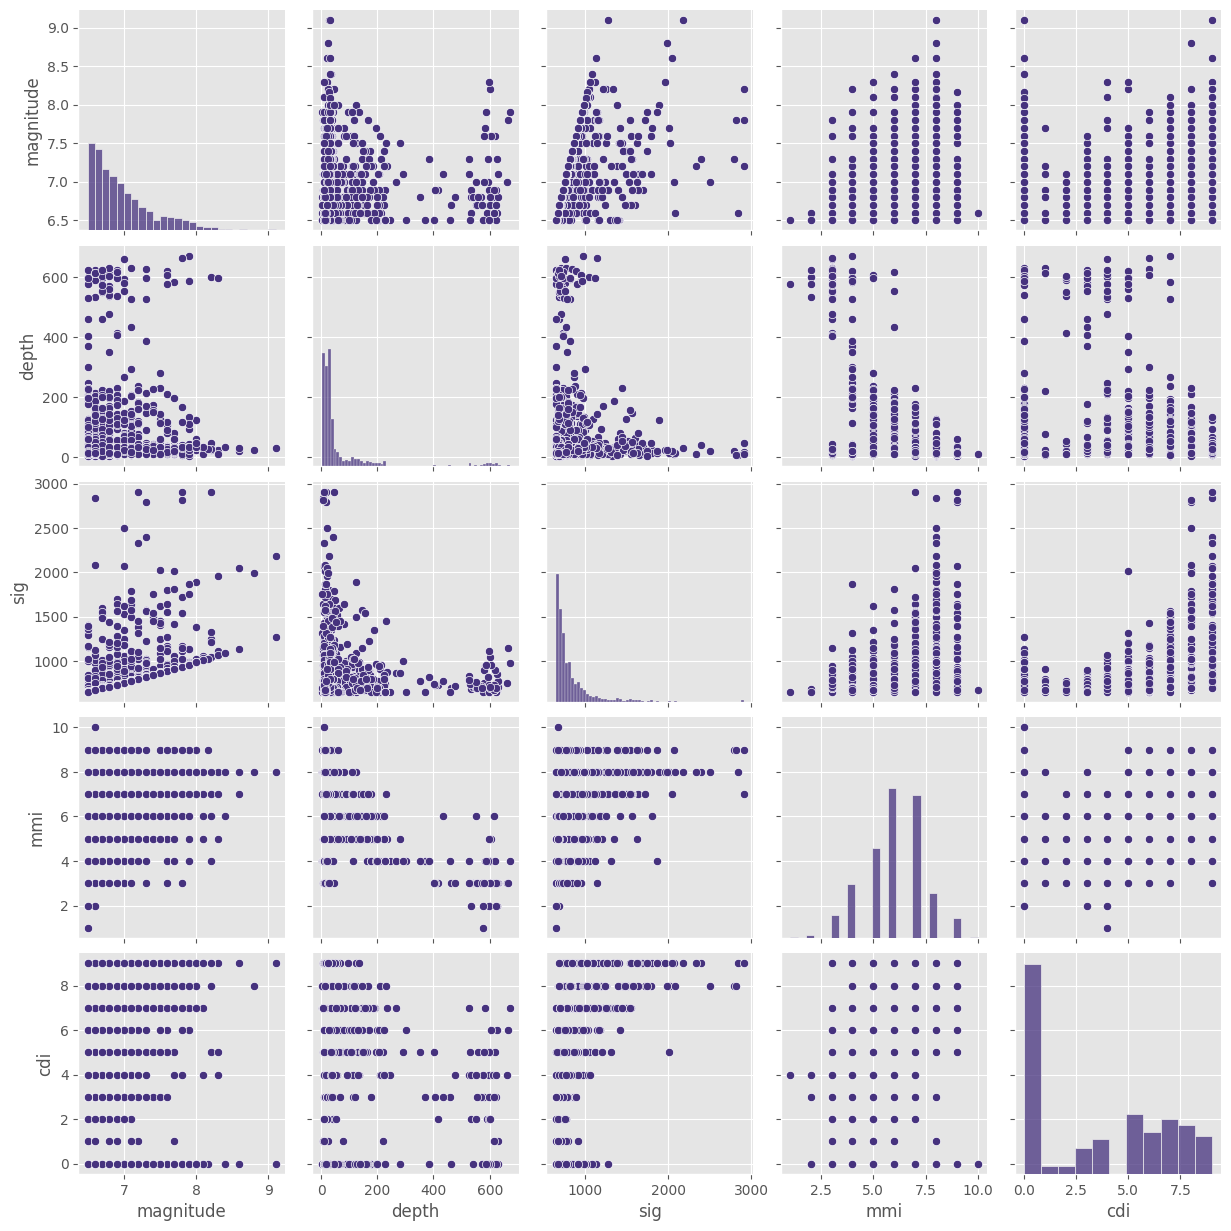

In [40]:
sns.pairplot(
    df[["magnitude","depth","sig","mmi","cdi"]]
)

plt.show()

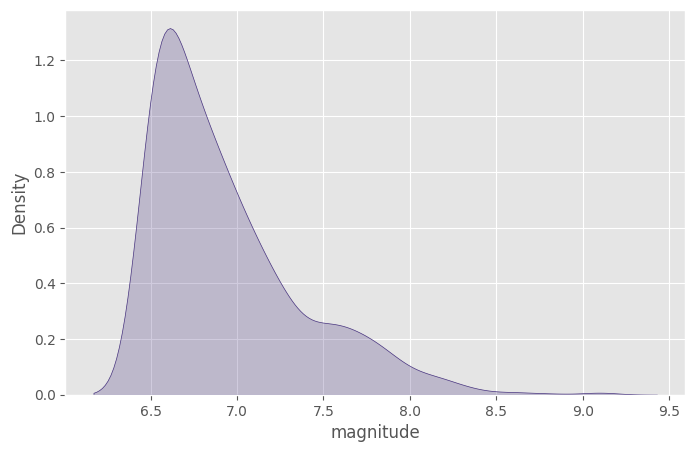

In [41]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["magnitude"],fill=True)

plt.show()

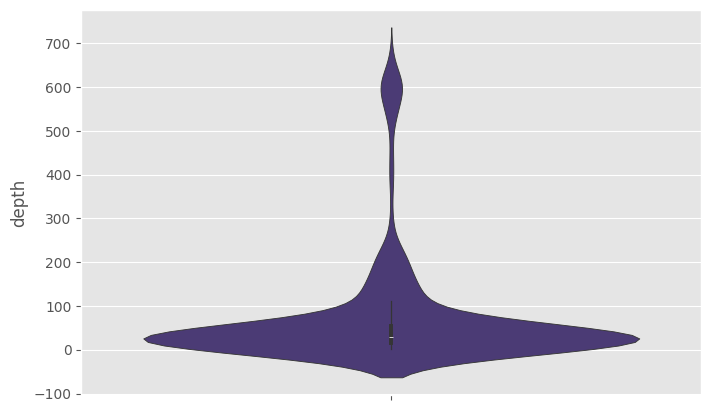

In [42]:
plt.figure(figsize=(8,5))

sns.violinplot(y=df["depth"])

plt.show()

In [43]:
Q1=df["magnitude"].quantile(0.25)

Q3=df["magnitude"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df["magnitude"]<lower) | (df["magnitude"]>upper)]

print("Outliers :",len(outliers))

Outliers : 47


In [44]:
corr=df.corr(numeric_only=True)

corr["magnitude"].sort_values(ascending=False)

magnitude    1.000000
sig          0.512358
mmi          0.282275
cdi          0.163170
nst          0.091427
Hour         0.022847
Day          0.019070
depth        0.017083
tsunami     -0.001213
Month       -0.002377
longitude   -0.010710
latitude    -0.017505
Year        -0.036082
dmin        -0.081518
gap         -0.087029
Name: magnitude, dtype: float64

In [53]:
print(df["magnitude"].describe())

print(df["magnitude"].min())

print(df["magnitude"].max())

print(df["magnitude"].head(20))

count    1000.000000
mean        6.940150
std         0.438148
min         6.500000
25%         6.600000
50%         6.800000
75%         7.100000
max         9.100000
Name: magnitude, dtype: float64
6.5
9.1
0     6.5
1     6.5
2     6.6
3     7.2
4     7.3
5     6.6
6     6.9
7     7.2
8     6.6
9     7.1
10    7.7
11    7.6
12    6.6
13    7.1
14    7.1
15    6.7
16    7.0
17    6.5
18    7.0
19    6.5
Name: magnitude, dtype: float64


In [55]:
df["Risk_Score"]=(
    df["magnitude"]*0.5+
    df["mmi"]*0.2+
    df["cdi"]*0.2+
    df["sig"]/1000
)

In [56]:
# Create Damage_Level using Risk Score

q1 = df["Risk_Score"].quantile(0.25)
q2 = df["Risk_Score"].quantile(0.50)
q3 = df["Risk_Score"].quantile(0.75)

df["Damage_Level"] = pd.cut(
    df["Risk_Score"],
    bins=[-float("inf"), q1, q2, q3, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

print(df["Damage_Level"].value_counts())

Damage_Level
Low         258
Severe      250
High        248
Moderate    244
Name: count, dtype: int64


In [64]:
X = df.drop(columns=["Damage_Level", "Risk_Score"])

y = df["Damage_Level"]

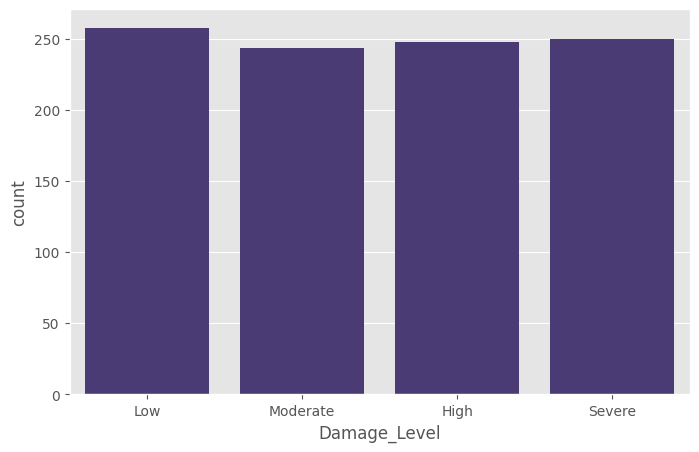

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Damage_Level",
    data=df,
    order=["Low","Moderate","High","Severe"]
)

plt.show()

In [66]:
df.to_csv("earthquake_cleaned.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [67]:
df.shape

(1000, 25)

In [68]:
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,Year,Month,Day,Hour,Damage_Level,Risk_Score
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu,2023,8,16,12,High,6.107
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN,2023,7,19,0,High,6.825
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,2023,7,17,3,High,6.599
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN,2023,7,16,6,Severe,6.860
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN,2023,7,16,6,Moderate,5.470


In [69]:
print("""
Exploratory Data Analysis Completed Successfully

✔ Missing Values Checked
✔ Duplicate Rows Removed
✔ Date Features Created
✔ Outliers Detected
✔ 15+ Visualizations Created
✔ Damage_Level Target Generated

Dataset Ready for Feature Engineering.
""")


Exploratory Data Analysis Completed Successfully

✔ Missing Values Checked
✔ Duplicate Rows Removed
✔ Date Features Created
✔ Outliers Detected
✔ 15+ Visualizations Created
✔ Damage_Level Target Generated

Dataset Ready for Feature Engineering.

